# End-of-day (EOD) Data Preparation 
This notebook prepares structured stock market data which will be fed to later ML models. The raw end-of-day (EOD) stock prices are transformed into normalized feature matrices. Also, the raw closing prices for each day will be saved in order to later calculate the ground truth values for comparison during training. All the data files created in this notebook are saved under the `data/2013-01-01` folder.

**Output files**:  
- `<MARKET>_raw_prices.npy`: Raw prices for return ratio calculation.  
- `<MARKET>_<TICKER>_1.csv`: Normalized features for each stock.  

## Imports and paths setup

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
# Define paths
data_path = os.path.join('..', '..', 'data')
market_name = 'NYSE'
eod_data_path = os.path.join(data_path, 'google_finance')
tickers_file = os.path.join(data_path, f'{market_name}_tickers_qualify_dr-0.98_min-5_smooth.csv')
trading_dates_file = os.path.join(data_path, f'{market_name}_aver_line_dates.csv')
output_path = os.path.join(data_path, '2013-01-01')
os.makedirs(output_path, exist_ok=True)
date_format = '%Y-%m-%d %H:%M:%S'

## Data collection and preprocessing
The first step of the project is to collect the stocks and their historical values. The data has been already downloaded from `google_finance` and saved into CSV files in the `data` folder. The daily stock data columns are Open, High, Low, Close, Volume.

In [3]:
tickers = np.genfromtxt(tickers_file, dtype=str, delimiter='\t', skip_header=False)
print(f"#tickers: {len(tickers)}")
tickers[0]

#tickers: 1737


np.str_('A')

In [4]:
trading_dates = np.genfromtxt(trading_dates_file, dtype=str, delimiter=',', skip_header=False)
print(f"#trading dates: {len(trading_dates)}")
trading_dates[0]

#trading dates: 1274


np.str_('2012-11-19 16:00:00')

In [5]:
tra_dates_index = {d: i for i, d in enumerate(trading_dates)}
index_tra_dates = {i: d for i, d in enumerate(trading_dates)}

In [6]:
def read_eod_data(tickers, eod_data_path, market_name):
    data_EOD = []
    for ticker in tickers:
        filename = f"{market_name}_{ticker}_30Y.csv"
        path = os.path.join(eod_data_path, filename)
        eod = np.genfromtxt(path, dtype=str, delimiter=',', skip_header=True)
        data_EOD.append(eod)
    return data_EOD

data_EOD = read_eod_data(tickers, eod_data_path, market_name)
assert len(tickers) == len(data_EOD)
print(f"#stocks' EOD data read: {len(data_EOD)}")

#stocks' EOD data read: 1737


In [7]:
data_EOD[0][0]

array(['1999-11-18 16:00:00-05:00', '0.0', '49.5', '40.0', '42.75',
       '44733600'], dtype='<U25')

In [8]:
# Convert EOD strings to float array with indexed dates
def transfer_EOD_str(selected_EOD_str, tra_date_index):
    selected_EOD = np.zeros(selected_EOD_str.shape, dtype=float)
    for row, daily_EOD in enumerate(selected_EOD_str):
        date_str = daily_EOD[0].replace('-05:00', '').replace('-04:00', '')
        selected_EOD[row][0] = tra_date_index[date_str]
        for col in range(1, selected_EOD_str.shape[1]):
            selected_EOD[row][col] = float(daily_EOD[col])
    return selected_EOD

## Feature engineering
### Normalized features
For each stock on each day, the following features are created and then normalized:
- 5-day Moving Average (MA)
- 10-day Moving Average (MA)
- 20-day Moving Average (MA)
- 30-day Moving Average (MA)
- Closing Price

The normalization step uses **Z-Score normalization** over a fixed rolling window $W$ of 30 days. For a feature $x_t$ at time $t$, the rolling Z-score is:
$$
z_t = \frac{x_t - \mu_{\text{window}}}{\sigma_{\text{window}}}, \quad
$$
where $\mu_{\text{window}}$ and $\sigma_{\text{window}}$ are the feature's mean and standard deviation computed over the window ($[t-W, t]$).
### Raw close prices
It is also saved a single NumPy file, `<MARKET>_raw_prices.npy`. This matrix of shape `(num_tickers, num_days)` contains the un-normalized, raw closing prices and is perfectly aligned with the feature files. This file is essential for the main training notebook to accurately calculate the 1-day return ratio, which serves as the ground truth target for the models.

In [9]:
def generate_feature_for_stock(single_EOD, ticker, trading_dates, tra_dates_index, begin_date, pad_begin=29, return_days=1, norm_window=30):
    """
    Processes a single stock's EOD data.
    Returns:
        - A matrix of Z-score normalized features.
        - A vector of raw closing prices perfectly aligned with the feature matrix.
    """
    # Find the starting row in the EOD data based on the begin_date
    begin_date_row = next(
        (i for i, row in enumerate(single_EOD)
         if datetime.strptime(row[0].replace('-05:00', '').replace('-04:00', ''), date_format) > begin_date),
        -1
    )
    # Define the number of days for which features will be generated
    num_feature_days = len(trading_dates) - pad_begin
    
    if begin_date_row == -1:
        # If no data, return placeholder arrays of the correct final shape
        return (np.ones((num_feature_days, 6)) * -1234,
                np.ones(num_feature_days) * -1234)

    selected_EOD_str = single_EOD[begin_date_row:]
    selected_EOD = transfer_EOD_str(selected_EOD_str, tra_dates_index)

    begin_index = next((i for i, row in enumerate(selected_EOD) if int(row[0]) >= pad_begin), -1)
    if begin_index == -1:
        return (np.ones((num_feature_days, 6)) * -1234,
                np.ones(num_feature_days) * -1234)

    # --- 1) Calculate UN-NORMALIZED features ---
    closing_prices = selected_EOD[:, 4]
    mov_avg = np.zeros((selected_EOD.shape[0], 4))
    for row in range(begin_index, selected_EOD.shape[0]):
        idx = int(selected_EOD[row][0])
        vals = [0.0] * 4
        counts = [0] * 4
        for offset in range(30):
            if row - offset < 0: break
            gap = idx - selected_EOD[row - offset][0]
            close = selected_EOD[row - offset][4]
            if gap < 5: vals[0] += close; counts[0] += 1
            if gap < 10: vals[1] += close; counts[1] += 1
            if gap < 20: vals[2] += close; counts[2] += 1
            if gap < 30: vals[3] += close; counts[3] += 1
        for i in range(4):
            if counts[i] > 0:
                mov_avg[row][i] = vals[i] / counts[i]

    unnormalized_features = np.hstack((mov_avg, closing_prices[:, np.newaxis]))

    # --- 2) Create final matrices with ROLLING Z-SCORE NORMALIZATION ---
    features = np.ones((num_feature_days, 6)) * -1234
    raw_prices_for_features = np.ones(num_feature_days) * -1234 # For alignment
    
    for row in range(num_feature_days):
        features[row, 0] = row

    for row_idx in range(begin_index, selected_EOD.shape[0]):
        cur_day_index = int(selected_EOD[row_idx][0])
        target_feature_row = cur_day_index - pad_begin
        if target_feature_row < 0:
            continue

        window_start_idx = max(0, row_idx - norm_window + 1)
        feature_window = unnormalized_features[window_start_idx:row_idx+1, :]
        
        mean = np.mean(feature_window, axis=0)
        std = np.std(feature_window, axis=0)
        std[std < 1e-8] = 1.0
        
        current_features = unnormalized_features[row_idx]
        normalized_features = (current_features - mean) / std
        
        features[target_feature_row, 1:6] = normalized_features
        # Store the raw closing price for this exact day
        raw_prices_for_features[target_feature_row] = closing_prices[row_idx]

    return features, raw_prices_for_features

In [10]:
# Run Feature Generation on All Tickers
begin_date = datetime.strptime('2012-11-19 00:00:00', date_format)
return_days = 1

num_feature_days = len(trading_dates) - 29

# Initialize the matrices
all_feature_matrices = np.zeros((len(tickers), num_feature_days, 6))
all_raw_prices = np.zeros((len(tickers), num_feature_days))

for i, (ticker, eod_data) in enumerate(zip(tickers, data_EOD)):
    print(f"Processing {ticker} ({i + 1}/{len(tickers)})")
    
    # The function now returns two aligned arrays
    feature_matrix, raw_price_vector = generate_feature_for_stock(
        eod_data, ticker, trading_dates, tra_dates_index,
        begin_date, pad_begin=29, return_days=return_days
    )
    
    # Save the normalized features for each stock individually
    np.savetxt(os.path.join(output_path, f"{market_name}_{ticker}_{return_days}.csv"), 
               feature_matrix, fmt="%.6f", delimiter=",")
    
    # Store the results in our master matrices
    all_feature_matrices[i, :, :] = feature_matrix
    all_raw_prices[i, :] = raw_price_vector

raw_price_output_path = os.path.join(output_path, f'{market_name}_raw_prices.npy')
np.save(raw_price_output_path, all_raw_prices)

print(f"\nFinished processing all tickers.")
print(f"Shape of saved raw prices matrix: {all_raw_prices.shape}")
print(f"Saved raw prices to: {raw_price_output_path}")

Processing A (1/1737)
Processing AAN (2/1737)
Processing AAP (3/1737)
Processing AAT (4/1737)
Processing AB (5/1737)
Processing ABB (6/1737)
Processing ABBV (7/1737)
Processing ABC (8/1737)
Processing ABG (9/1737)
Processing ABM (10/1737)
Processing ABR (11/1737)
Processing ABT (12/1737)
Processing ABX (13/1737)
Processing ACC (14/1737)
Processing ACCO (15/1737)
Processing ACH (16/1737)
Processing ACM (17/1737)
Processing ACN (18/1737)
Processing ACP (19/1737)
Processing ACRE (20/1737)
Processing ADC (21/1737)
Processing ADM (22/1737)
Processing ADS (23/1737)
Processing ADX (24/1737)
Processing AEB (25/1737)
Processing AED (26/1737)
Processing AEE (27/1737)
Processing AEH (28/1737)
Processing AEL (29/1737)
Processing AEM (30/1737)
Processing AEO (31/1737)
Processing AEP (32/1737)
Processing AER (33/1737)
Processing AES (34/1737)
Processing AET (35/1737)
Processing AFB (36/1737)
Processing AFC (37/1737)
Processing AFG (38/1737)
Processing AFL (39/1737)
Processing AFT (40/1737)
Processin

In [11]:
all_raw_prices.shape

(1737, 1245)

In [12]:
all_feature_matrices.shape

(1737, 1245, 6)

Plotting the MA features for an example stock.

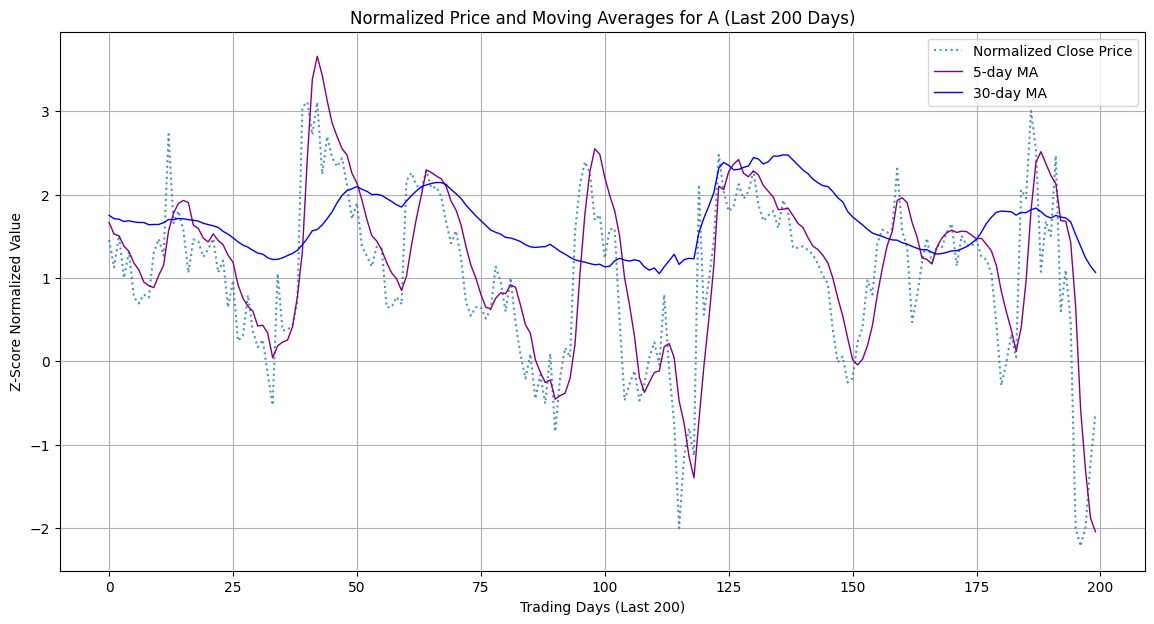

In [18]:
# Example – Plot Feature for One Stock
example_features = all_feature_matrices[0]

# Filter out rows with placeholder values
valid_features = example_features[example_features[:, 1] != -1234]

# Select the last 200 days of valid data
num_days_to_plot = 200
plot_features = valid_features[-num_days_to_plot:]

plt.figure(figsize=(14, 7))

# The last column of the feature matrix is the z-score normalized closing price.
plt.plot(plot_features[:, 5], label='Normalized Close Price', linestyle=':', alpha=0.8)

plt.plot(plot_features[:, 1], label='5-day MA', color='purple', linewidth=1)
#plt.plot(plot_features[:, 2], label='10-day MA', color='green', linewidth=1)
#plt.plot(plot_features[:, 3], label='20-day MA', color='red', linewidth=1)
plt.plot(plot_features[:, 4], label='30-day MA', color='blue', linewidth=1)

plt.title(f"Normalized Price and Moving Averages for {example_ticker} (Last {num_days_to_plot} Days)")
plt.xlabel(f"Trading Days (Last {num_days_to_plot})")
plt.ylabel("Z-Score Normalized Value")
plt.legend()
plt.grid(True)
plt.show()